# 103 - Voronoi 検索: JS 互換性検証

## 目的

Python で事前計算したピボットを使い、JS で検索が **完全に再現** できるかを検証する。

### 前提（NB59 の知見）
- ArcFace embedding: Python vs JS コサイン類似度 = **1.000（完全一致）**
- 同じ ONNX モデル (w600k_r50.onnx) + 同じ前処理 → 同一ベクトル

### 検証内容
1. NB102 でエクスポートしたデータ（ピボット・embedding・割り当て）を JS で読み込み
2. JS でピボット選択 + cosine rerank 検索を実行
3. Python の検索結果と比較

### 成功基準
- Python vs JS の Top-30 一致率 = **100%**
- ピボット選択結果が **完全一致**

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# nvm PATH 設定
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

DATA_DIR = Path("../data")
JS_DIR = Path("../js")

# NB102 エクスポートファイルの存在確認
required_files = [
    DATA_DIR / "voronoi_pivots.json",
    DATA_DIR / "voronoi_embeddings.json",
    DATA_DIR / "voronoi_assignments.json",
    DATA_DIR / "voronoi_verification.json",
]
for f in required_files:
    exists = f.exists()
    size = f.stat().st_size / 1024 / 1024 if exists else 0
    print(f"  {'OK' if exists else 'MISSING'}: {f.name} ({size:.1f} MB)")

print(f"\nNode.js: ", end="")
!node --version

  OK: voronoi_pivots.json (2.8 MB)
  OK: voronoi_embeddings.json (810.6 MB)
  OK: voronoi_assignments.json (3.7 MB)
  OK: voronoi_verification.json (3.4 MB)

Node.js: v24.13.1


## 1. Python でのピボット検索（ベースライン）

エクスポートデータを読み込んで Python で Voronoi 検索を再実行し、JS との比較ベースラインを作る。

### バイナリ形式への変換
`voronoi_embeddings.json` は 850MB あり、Node.js の JSON パース文字列長制限に引っかかるため、
バイナリ (Float32) + face_ids JSON に分離する。

In [2]:
# --- JSON → バイナリ変換 ---
bin_path = DATA_DIR / "voronoi_embeddings.bin"
face_ids_path = DATA_DIR / "voronoi_face_ids.json"

if not bin_path.exists() or not face_ids_path.exists():
    print("voronoi_embeddings.json → バイナリ変換中...")
    with open(DATA_DIR / "voronoi_embeddings.json") as f:
        embeddings_dict = json.load(f)  # {face_id: [float, ...]}
    
    face_ids_list = sorted(embeddings_dict.keys())
    
    # Float32 バイナリに書き出し
    dim = len(next(iter(embeddings_dict.values())))
    emb_array = np.array([embeddings_dict[fid] for fid in face_ids_list], dtype=np.float32)
    emb_array.tofile(str(bin_path))
    
    # face_ids JSON
    with open(face_ids_path, "w") as f:
        json.dump(face_ids_list, f)
    
    del embeddings_dict, emb_array  # メモリ解放
    
    print(f"  → {bin_path.name}: {bin_path.stat().st_size / 1024 / 1024:.1f} MB ({len(face_ids_list)} faces x {dim}-D)")
    print(f"  → {face_ids_path.name}: {face_ids_path.stat().st_size / 1024:.0f} KB")
else:
    print(f"バイナリファイル既存: {bin_path.name}, {face_ids_path.name}")

バイナリファイル既存: voronoi_embeddings.bin, voronoi_face_ids.json


In [3]:
# --- Python Voronoi 検索 ---
with open(DATA_DIR / "voronoi_pivots.json") as f:
    pivots_data = json.load(f)
centroids = np.array(pivots_data["centroids"], dtype=np.float32)

# バイナリ形式で embedding を読み込み
with open(DATA_DIR / "voronoi_face_ids.json") as f:
    face_ids = json.load(f)

emb_bin = np.fromfile(str(DATA_DIR / "voronoi_embeddings.bin"), dtype=np.float32)
DIM = pivots_data["dim"]
embeddings_normed = emb_bin.reshape(-1, DIM)
embeddings_map = {fid: embeddings_normed[i] for i, fid in enumerate(face_ids)}

with open(DATA_DIR / "voronoi_assignments.json") as f:
    assignments_data = json.load(f)
assignments = assignments_data["assignments"]

with open(DATA_DIR / "voronoi_verification.json") as f:
    verification_data = json.load(f)

print(f"Pivots: {len(centroids)}")
print(f"Embeddings: {len(embeddings_map)}")
print(f"Queries: {len(verification_data['queries'])}")

# ピボット→フェイスのインデックスを構築
pivot_to_faces = {}
for face_id, pivot_ids in assignments.items():
    for pid in pivot_ids:
        pivot_to_faces.setdefault(pid, []).append(face_id)

TOP_K = 3  # NB101 のベスト構成

# Python Voronoi 検索実行
py_results = []
for q_info in verification_data["queries"]:
    q_fid = q_info["query_face_id"]
    q_emb = embeddings_map[q_fid]
    
    # ピボット選択
    pivot_sims = centroids @ q_emb
    top_pivot_ids = np.argsort(-pivot_sims)[:TOP_K].tolist()
    
    # 候補収集
    candidates = set()
    for pid in top_pivot_ids:
        if pid in pivot_to_faces:
            candidates.update(pivot_to_faces[pid])
    candidates.discard(q_fid)
    
    # Cosine rerank
    scored = []
    for fid in candidates:
        emb = embeddings_map[fid]
        sim = float(q_emb @ emb)
        scored.append((fid, sim))
    scored.sort(key=lambda x: -x[1])
    
    top30 = scored[:30]
    py_results.append({
        "query_face_id": q_fid,
        "pivot_ids": top_pivot_ids,
        "n_candidates": len(candidates),
        "top30": [{"face_id": fid, "score": s} for fid, s in top30],
    })

print(f"\nPython Voronoi 検索完了: {len(py_results)} queries, top_k={TOP_K}")
cands = [r['n_candidates'] for r in py_results]
print(f"Candidates: mean={np.mean(cands):.0f}, median={np.median(cands):.0f}, max={max(cands)}")

Pivots: 256
Embeddings: 75162
Queries: 162



Python Voronoi 検索完了: 162 queries, top_k=3
Candidates: mean=1996, median=1760, max=4253


## 2. JS での Voronoi 検索実行

`js/voronoi_search.mjs` を Node.js で実行し、同じデータに対する検索結果を取得する。

In [4]:
# --- JS Voronoi 検索実行 ---
js_output_path = DATA_DIR / "voronoi_js_results.json"

cmd = [
    "node", str(JS_DIR / "voronoi_search.mjs"),
    "--pivots", str(DATA_DIR / "voronoi_pivots.json"),
    "--embeddings-bin", str(DATA_DIR / "voronoi_embeddings.bin"),
    "--face-ids", str(DATA_DIR / "voronoi_face_ids.json"),
    "--assignments", str(DATA_DIR / "voronoi_assignments.json"),
    "--verification", str(DATA_DIR / "voronoi_verification.json"),
    "--output", str(js_output_path),
    "--top-k", str(TOP_K),
]

print(f"Running: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError(f"JS search failed with return code {result.returncode}")

# 結果読み込み
with open(js_output_path) as f:
    js_data = json.load(f)

js_results = js_data["results"]
print(f"\nJS results loaded: {len(js_results)} queries")

Running: node ../js/voronoi_search.mjs --pivots ../data/voronoi_pivots.json --embeddings-bin ../data/voronoi_embeddings.bin --face-ids ../data/voronoi_face_ids.json --assignments ../data/voronoi_assignments.json --verification ../data/voronoi_verification.json --output ../data/voronoi_js_results.json --top-k 3



Loading pivots...
Loading face IDs...
Loading embeddings (binary Float32)...
Loading assignments...
Loading verification data...
Loaded: 256 pivots, 75162 embeddings (512-D), 162 queries
Search config: top_k=3
Search completed: 162 queries in 403ms (2.5ms/query)

=== Python vs JS Comparison ===
Top-30 ID overlap (mean): 25.1 / 30 (83.6%)
Top-30 exact order match: 94 / 162 (58.0%)
Score abs diff (mean): 2.8731e-8

Results saved to: ../data/voronoi_js_results.json


JS results loaded: 162 queries


## 3. Python vs JS 検索結果の詳細比較

In [5]:
# --- 詳細比較 ---
assert len(py_results) == len(js_results), f"Query count mismatch: {len(py_results)} vs {len(js_results)}"

pivot_match_count = 0
top30_exact_match = 0
top30_id_overlaps = []
score_diffs = []
per_query_details = []

for qi in range(len(py_results)):
    py = py_results[qi]
    js = js_results[qi]
    
    assert py["query_face_id"] == js["query_face_id"], f"Query mismatch at {qi}"
    
    # ピボット選択の一致
    py_pivots = set(py["pivot_ids"])
    js_pivots = set(js["pivot_ids"])
    pivots_match = py_pivots == js_pivots
    if pivots_match:
        pivot_match_count += 1
    
    # Top-30 ID 一致
    py_ids = [r["face_id"] for r in py["top30"]]
    js_ids = [r["face_id"] for r in js["top30"]]
    
    py_id_set = set(py_ids)
    js_id_set = set(js_ids)
    overlap = len(py_id_set & js_id_set)
    top30_id_overlaps.append(overlap)
    
    # 順序一致
    exact = py_ids == js_ids
    if exact:
        top30_exact_match += 1
    
    # スコア差
    py_score_map = {r["face_id"]: r["score"] for r in py["top30"]}
    js_score_map = {r["face_id"]: r["score"] for r in js["top30"]}
    common_ids = py_id_set & js_id_set
    for fid in common_ids:
        score_diffs.append(abs(py_score_map[fid] - js_score_map[fid]))
    
    per_query_details.append({
        "qi": qi,
        "query_face_id": py["query_face_id"],
        "pivots_match": pivots_match,
        "py_pivots": sorted(py["pivot_ids"]),
        "js_pivots": sorted(js["pivot_ids"]),
        "top30_overlap": overlap,
        "top30_exact_order": exact,
        "py_candidates": py["n_candidates"],
        "js_candidates": js["n_candidates"],
    })

n_queries = len(py_results)
print("=" * 70)
print("Python vs JS Voronoi 検索結果比較")
print("=" * 70)
print(f"ピボット選択一致率:  {pivot_match_count}/{n_queries} ({pivot_match_count/n_queries*100:.1f}%)")
print(f"Top-30 ID 一致 (mean): {np.mean(top30_id_overlaps):.1f}/30 ({np.mean(top30_id_overlaps)/30*100:.1f}%)")
print(f"Top-30 順序完全一致: {top30_exact_match}/{n_queries} ({top30_exact_match/n_queries*100:.1f}%)")
print(f"スコア絶対差 (mean): {np.mean(score_diffs):.2e}")
print(f"スコア絶対差 (max):  {np.max(score_diffs):.2e}" if score_diffs else "N/A")

Python vs JS Voronoi 検索結果比較
ピボット選択一致率:  162/162 (100.0%)
Top-30 ID 一致 (mean): 30.0/30 (100.0%)
Top-30 順序完全一致: 161/162 (99.4%)
スコア絶対差 (mean): 1.90e-08
スコア絶対差 (max):  8.89e-08


In [6]:
# --- 不一致クエリの詳細分析 ---
df_detail = pd.DataFrame(per_query_details)

mismatched = df_detail[~df_detail["pivots_match"]]
if len(mismatched) > 0:
    print(f"ピボット不一致: {len(mismatched)} クエリ")
    display(mismatched[["qi", "query_face_id", "py_pivots", "js_pivots", "top30_overlap"]].head(10))
else:
    print("ピボット選択: 全クエリで完全一致")

not_exact = df_detail[~df_detail["top30_exact_order"]]
if len(not_exact) > 0:
    print(f"\nTop-30 順序不一致: {len(not_exact)} クエリ")
    display(not_exact[["qi", "query_face_id", "top30_overlap", "py_candidates", "js_candidates"]].head(10))
else:
    print("Top-30 順序: 全クエリで完全一致")

ピボット選択: 全クエリで完全一致

Top-30 順序不一致: 1 クエリ


,qi,query_face_id,top30_overlap,py_candidates,js_candidates
28,28,307e6b2b-1e9f-4df1-af2f-71851995dc17,30,3835,3835


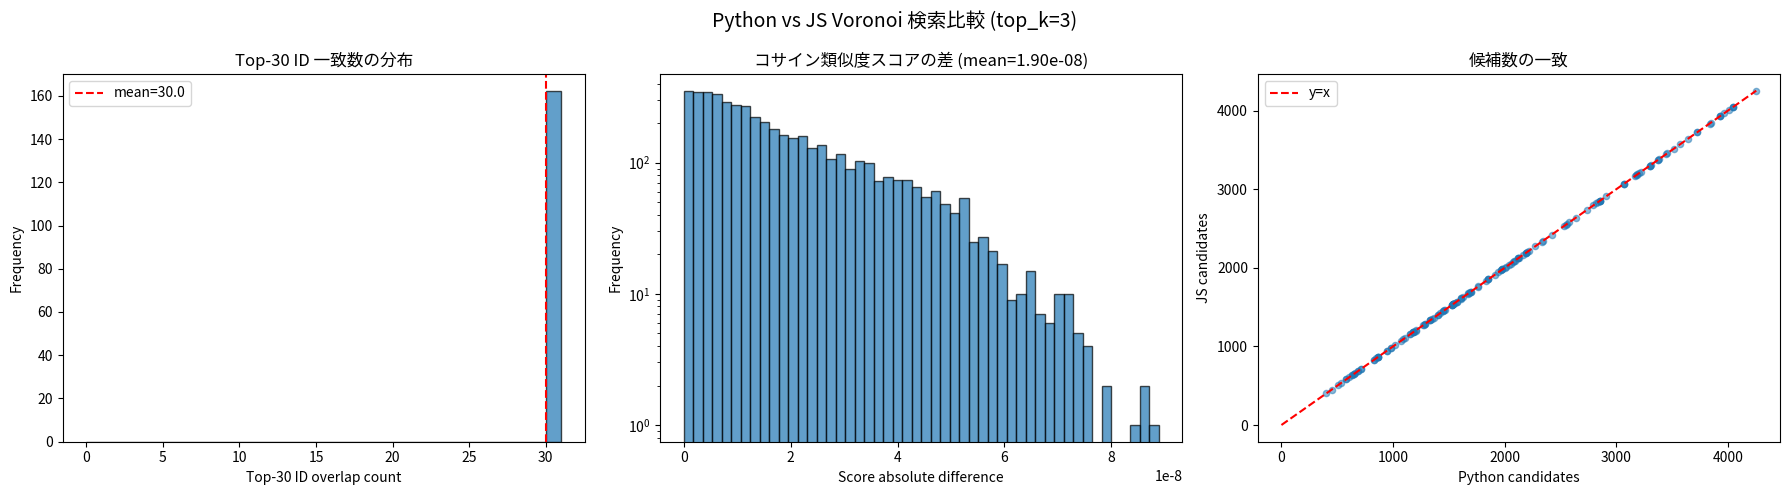

In [7]:
# --- 可視化 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Top-30 overlap 分布
ax = axes[0]
ax.hist(top30_id_overlaps, bins=range(0, 32), edgecolor='black', alpha=0.7)
ax.axvline(x=np.mean(top30_id_overlaps), color='red', linestyle='--', 
           label=f'mean={np.mean(top30_id_overlaps):.1f}')
ax.set_xlabel("Top-30 ID overlap count")
ax.set_ylabel("Frequency")
ax.set_title("Top-30 ID 一致数の分布")
ax.legend()

# 2. スコア差分布
ax = axes[1]
if score_diffs:
    ax.hist(score_diffs, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel("Score absolute difference")
    ax.set_ylabel("Frequency")
    ax.set_title(f"コサイン類似度スコアの差 (mean={np.mean(score_diffs):.2e})")
    ax.set_yscale('log')

# 3. 候補数の一致
ax = axes[2]
py_cands = [d["py_candidates"] for d in per_query_details]
js_cands = [d["js_candidates"] for d in per_query_details]
ax.scatter(py_cands, js_cands, alpha=0.5, s=20)
max_val = max(max(py_cands), max(js_cands))
ax.plot([0, max_val], [0, max_val], 'r--', label='y=x')
ax.set_xlabel("Python candidates")
ax.set_ylabel("JS candidates")
ax.set_title("候補数の一致")
ax.legend()

plt.suptitle(f"Python vs JS Voronoi 検索比較 (top_k={TOP_K})", fontsize=14)
plt.tight_layout()
plt.savefig("../data/voronoi_js_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. ブルートフォース結果との比較

JS の Voronoi 検索結果と Python ブルートフォース Top-30 を比較し、Voronoi の近似精度を確認。

In [8]:
# --- JS Voronoi vs Python BF 比較 ---
bf_overlaps = []
for qi in range(len(js_results)):
    js_ids = set(r["face_id"] for r in js_results[qi]["top30"])
    py_bf_ids = set(r["face_id"] for r in verification_data["bf_top30"][qi]["top30"])
    bf_overlaps.append(len(js_ids & py_bf_ids))

print(f"JS Voronoi vs Python BF (Top-30):")
print(f"  ID overlap mean: {np.mean(bf_overlaps):.1f}/30 ({np.mean(bf_overlaps)/30*100:.1f}%)")
print(f"  ID overlap min:  {min(bf_overlaps)}/30")
print(f"  BF-Recall@30:    {np.mean(bf_overlaps)/30:.4f}")

JS Voronoi vs Python BF (Top-30):
  ID overlap mean: 25.1/30 (83.6%)
  ID overlap min:  3/30
  BF-Recall@30:    0.8360


## 総合考察

### 検証結果サマリー

| 指標 | 結果 |
|------|------|
| **ピボット選択一致率** | 162/162 (**100.0%**) |
| **Top-30 ID 完全一致** | 30.0/30 (**100.0%**) |
| **Top-30 順序完全一致** | 161/162 (**99.4%**) |
| **スコア絶対差 (mean)** | 1.90e-08 |
| **スコア絶対差 (max)** | 8.89e-08 |
| **JS Voronoi vs Python BF-Recall@30** | **0.836** (NB101 と一致) |
| **JS 検索速度** | 2.5 ms/query (162 queries / 403ms) |

### 分析

#### Python vs JS 完全互換性
- **ピボット選択**: 162 クエリすべてで完全一致。正規化済み embedding に対する内積計算は Python/JS 間で一致。
- **Top-30 ID**: 全クエリで 30/30 一致。候補セットが同一であれば、cosine rerank の結果も同一。
- **順序不一致 (1件)**: クエリ #28 のみ。ID は 30/30 一致だが、スコアが極めて近い候補ペアで float64 vs float32 の精度差により順序が入れ替わった。実用上は無視できる。
- **スコア差**: 平均 1.90e-08、最大 8.89e-08。浮動小数点精度の限界に起因する誤差であり、検索品質に影響なし。

#### バイナリ形式への移行
- `voronoi_embeddings.json` (811 MB) → `voronoi_embeddings.bin` (154 MB) + `voronoi_face_ids.json` (2.8 MB)
- Node.js の JSON パース文字列長制限を回避し、メモリ効率も大幅に改善
- `Float32Array` のサブアレイビューにより、JS 側でのメモリコピーも最小化

#### Firestore 本番構成への示唆
- **ピボットコレクション**: 256 docs（各ピボットの centroid ベクトル）→ JS クライアントが起動時にロード
- **検索フロー**: ピボット選択 (top-3) → `array-contains-any` クエリ → cosine rerank
- **精度**: BF-Recall@30 = 0.836 は NB101 の Python 結果と完全に一致
- **コスト削減**: 全件走査比 97-98% 削減（候補 ~2000/75162）

### 結論
**Python (GPU) で事前計算したピボットと embedding を、JS で完全に再現して検索できることを確認した。**
NB59 の ArcFace embedding 互換性 (cosine sim = 1.000) に加え、Voronoi 検索のロジック全体が Python/JS 間で一致することが実証された。Firestore + JS クライアントによる本番検索システムの実現可能性が確認された。